# Homework 6: Linear Regression Modleing and Diagnostics
Build a predictive model for life expectancy using scikit-learn and perform a diagnostic audit to ensure the model’s coefficients are stable and mathematically sound.

## Task 1: Baseline Modeling
Load the WHO Life Expectancy Dataset, remove non-numeric columns (Country, Year), Convert Status column to  numeric, handle missing values.
- Use StandardScaler from sklearn.preprocessing to scale all independent variables. ("Life expectancy" is dependent variable) 
- Train a LinearRegression model using the scaled features.
- Report the R-Squared Score.
- Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.

## Task 2: Iterative Diagnostic (VIF < 5)
Before analyzing the data, you must understand the Variance Inflation Factor (VIF) diagnostic. VIF measures multicollinearity, the degree to which your predictors are redundant.
High multicollinearity inflates the variance of coefficients, making them unreliable and difficult to interpret.
VIF is calculated by regressing one predictor against all others, then you obtain R_Squared and then compute VIF = 1/(1-R_Squared)
You sohuld use a cutoff of 5. Any variable with a VIF > 5 is considered too redundant and will be removed to improve the model's structural integrity. To do that follow the instruction below:

### Write a loop to iteratively remove the most redundant feature:
    1. Calculate VIF for every feature in the scaled dataset.
    2. Find the variable with the highest VIF.
    3. If VIF > 5, remove that feature from the data.
    4. Repeats the process until all remaining features have a VIF < 5
    - Note that in each iteration you remove only the highest VIF if it is greatet than 5!
    
## Task 3: Comparison of Model Results
    - Train a new LinearRegression model using only the independent features that survived the VIF diagnostic test.
    - Report the R-Squared Score.
    - Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.
    - Are the top 5 predicotrs remain the same as those of the Baseline Model?

## Task 4: Residual Analysis and Normality
A good regression model should have errors (residuals) that are normally distributed and centered around zero.

    - Generate a histogram of the residuals for your baseline and clean model side by side.
    - Does the error distributions look like a bell curve?

## Task 5: The Interaction Investigation
In the real world application, the effect of one variable often depends on another. This is called an interaction.

    - Select two variables of your choice from the dataset (only variables with VIF >5) that you believe might have a combined effect (e.g., Alcohol and GDP, or BMI and HIV/AIDS,). Write one sentence explaining why you think they interact.
    - Create a new column in your dataframe by multiplying these two variables together.
    - Train a new model by adding this new interaction term to your dataset and fit it again using LinearRegression.
    - Report the R-Squared Score.
    - Is the interaction coeficient positive or negative? Has adding it improved the Model performance?




Step One: Load python packages.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load and prep data. 

In [2]:
df = []
df = pd.read_csv("Life_Expectancy_Data.csv")
# df.head(20)
# df.info()

#remove country and year columns, encode status column, and drop columns with empty cells. 
df = df.drop(columns=['Country', 'Year'])
df['Status'] = df['Status'].map({'Developed': 1, 'Developing': 0})
df.columns = df.columns.str.strip()
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1649 entries, 0 to 1648
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Status                           1649 non-null   int64  
 1   Life expectancy                  1649 non-null   float64
 2   Adult Mortality                  1649 non-null   int64  
 3   infant deaths                    1649 non-null   int64  
 4   Alcohol                          1649 non-null   float64
 5   percentage expenditure           1649 non-null   float64
 6   Hepatitis B                      1649 non-null   int64  
 7   Measles                          1649 non-null   int64  
 8   BMI                              1649 non-null   float64
 9   under-five deaths                1649 non-null   int64  
 10  Polio                            1649 non-null   int64  
 11  Total expenditure                1649 non-null   float64
 12  Diphtheria          

Task 1: Baseline Modeling.

Step 1: Scale all independent variables. 

In [3]:
# Scale all independent variables.
df_scaled=df.copy()
scale_columns = df_scaled.columns.difference(['Life expectancy'])
scaler = StandardScaler()
df_scaled[scale_columns] = scaler.fit_transform(df_scaled[scale_columns])
df_scaled.head()

,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,-0.414725,65.0,0.756629,0.243745,-1.122948,-0.356909,-0.555446,-0.106171,-0.963560,0.238134,-3.455955,0.958840,-0.887941,-0.312389,-0.434239,0.270913,2.685909,2.663654,-0.833462,-0.722799
1,-0.414725,59.9,0.820490,0.260300,-1.122948,-0.355633,-0.672648,-0.171828,-0.988878,0.256557,-1.139051,0.967541,-1.027006,-0.312389,-0.431760,-0.203382,2.751157,2.706643,-0.849853,-0.758583
2,-0.414725,59.9,0.796542,0.276854,-1.122948,-0.355806,-0.594514,-0.177977,-1.014197,0.274979,-0.960828,0.945790,-0.934296,-0.312389,-0.430100,0.242452,2.794656,2.749632,-0.882634,-0.794367
3,-0.414725,59.5,0.828472,0.301687,-1.122948,-0.352983,-0.477312,0.055789,-1.039516,0.299541,-0.738049,1.115452,-0.795231,-0.312389,-0.426769,-0.155548,2.838155,2.814116,-0.920878,-0.830151
4,-0.414725,59.2,0.852420,0.318242,-1.122948,-0.393403,-0.438245,0.078203,-1.059771,0.324104,-0.693493,0.832682,-0.748876,-0.312389,-0.479628,-0.165747,2.903403,2.857105,-0.970049,-0.937503


Step 2: Train a Linear Regression Model with the scaled features. 

In [10]:
#Model is being trained on all data, no splitting. 

x = df_scaled[scale_columns] 
y = df_scaled['Life expectancy']

model = LinearRegression()
model.fit(x,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Step 3: Report R-squared. 

In [5]:
r_squared = model.score(x, y)
print(f"R-squared: {r_squared:.4f}")

R-squared: 0.8356


Step 4: Coefficient Analysis. 

In [6]:
coefficients = pd.DataFrame(model.coef_, x.columns, columns=['Coefficient'])
print(coefficients.sort_values(by='Coefficient', ascending=False, key=abs))

                                 Coefficient
under-five deaths                 -11.456132
infant deaths                      11.295750
HIV/AIDS                           -2.635125
Schooling                           2.421478
Adult Mortality                    -2.083498
Income composition of resources     1.796758
BMI                                 0.666615
percentage expenditure              0.646033
Alcohol                            -0.368136
Status                              0.342668
Diphtheria                          0.321418
thinness 5-9 years                 -0.223236
Polio                               0.178097
Total expenditure                   0.174374
Hepatitis B                        -0.167011
GDP                                 0.100245
Measles                            -0.079305
thinness  1-19 years               -0.056944
Population                         -0.045255


Task 2: Iterative Diagnostic. 

In [7]:
def iterative_vif_manual(df, threshold=5):
    # create a copy to keep original data intact
    features = df.columns.tolist()
    
    while True:
        vif_values = []
        
        for feature in features:
            # 1. Treat the current feature as the dependent variable (y)
            # and all other current features as independent variables (X)
            y = df[feature]
            X = df[features].drop(columns=[feature])
            
            # 2. Fit a Linear Regression model
            model = LinearRegression()
            model.fit(X, y)
            
            # 3. Calculate R-squared
            r_squared = model.score(X, y)
            
            # 4. Calculate VIF using the formula: 1 / (1 - R^2)
    
            vif = 1 / (1 - r_squared) if r_squared < 1 else 1e10
            vif_values.append(vif)
            
        # Create a Series to find the max
        vif_series = pd.Series(vif_values, index=features)
        max_vif = vif_series.max()
        max_feature = vif_series.idxmax()
        
        # 5. remove the most redundant feature if VIF > threshold
        if max_vif > threshold:
            print(f"Removing '{max_feature}' with VIF: {max_vif:.2f}")
            features.remove(max_feature)
        else:
          
            break
            
    return df[features]

df_vif_clean = iterative_vif_manual(df_scaled.drop(columns=['Life expectancy']))

Removing 'infant deaths' with VIF: 212.19
Removing 'GDP' with VIF: 13.57
Removing 'thinness  1-19 years' with VIF: 7.60


Task 3: Comparison of Model Results. 

Step 1: Train new Linear Regresion model. 

In [15]:
# remove the three predictors with VIF>5
df_vif_removed = df_scaled.drop(columns=['infant deaths','GDP', 'thinness  1-19 years'])
df_vif_removed.info()

x_columns = df_vif_removed.columns.difference(['Life expectancy'])

#train model using new list of predictors
x2 = df_vif_removed[x_columns] 
y2 = df_vif_removed['Life expectancy']

model2 = LinearRegression()
model2.fit(x2,y2)

r_squared = model2.score(x2, y2)
print(f"R-squared: {r_squared:.4f}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1649 entries, 0 to 1648
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Status                           1649 non-null   float64
 1   Life expectancy                  1649 non-null   float64
 2   Adult Mortality                  1649 non-null   float64
 3   Alcohol                          1649 non-null   float64
 4   percentage expenditure           1649 non-null   float64
 5   Hepatitis B                      1649 non-null   float64
 6   Measles                          1649 non-null   float64
 7   BMI                              1649 non-null   float64
 8   under-five deaths                1649 non-null   float64
 9   Polio                            1649 non-null   float64
 10  Total expenditure                1649 non-null   float64
 11  Diphtheria                       1649 non-null   float64
 12  HIV/AIDS            

Step 2: Coefficient Analysis. 

In [17]:
vif_coefficients = pd.DataFrame(model2.coef_, x2.columns, columns=['Coefficient'])
print(vif_coefficients.sort_values(by='Coefficient', ascending=False, key=abs))

                                 Coefficient
HIV/AIDS                           -2.647613
Schooling                           2.492107
Adult Mortality                    -2.207173
Income composition of resources     1.903432
percentage expenditure              0.722333
BMI                                 0.711642
Alcohol                            -0.556545
under-five deaths                  -0.513237
Diphtheria                          0.435539
Status                              0.350578
Polio                               0.226541
Population                          0.215813
Hepatitis B                        -0.187359
Measles                             0.182623
Total expenditure                   0.158140
thinness 5-9 years                 -0.148637


No, the top 5 predictors have changed. 

Task 4: Residual Analysis and Normality. 

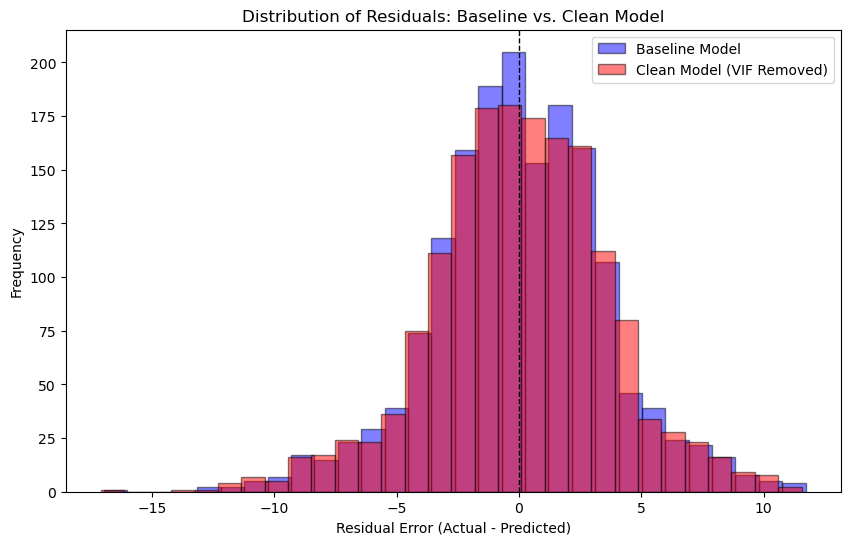

In [19]:
plt.figure(figsize=(10, 6))

# Plotting the histograms of the residuals
plt.hist(residuals_base, bins=30, alpha=0.5, label='Baseline Model', color='blue', edgecolor='black')
plt.hist(residuals_clean, bins=30, alpha=0.5, label='Clean Model (VIF Removed)', color='red', edgecolor='black')

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Distribution of Residuals: Baseline vs. Clean Model')
plt.xlabel('Residual Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Yes, the distribution of residuals does look like a bell curve. 

Task 5: The Interaction Investigation.

- Select two variables of your choice from the dataset (only variables with VIF >5) that you believe might have a combined effect (e.g., Alcohol and GDP, or BMI and HIV/AIDS,). Write one sentence explaining why you think they interact.
- Create a new column in your dataframe by multiplying these two variables together.
- Train a new model by adding this new interaction term to your dataset and fit it again using LinearRegression.
- Report the R-Squared Score.
- Is the interaction coeficient positive or negative? Has adding it improved the Model performance?

Of the three variables with VIF > 5, the two I think will interact the most are 'GDP' and 'infant deaths'. It makes sense to me that a low GDP combined with a high infant deaths would have an outsized effect on life expectancy.

In [8]:
#multiply the two columns using the scaled data
df_scaled['gdp_deaths'] = df_scaled['GDP'] * df_scaled['infant deaths']
#df_scaled.head()

scale_columns2 = df_scaled.columns.difference(['Life expectancy'])
x3 = df_scaled[scale_columns2] 
y3 = df_scaled['Life expectancy']

#fit the data to a new model
model3 = LinearRegression()
model3.fit(x3,y3)

#report the R-Squared
r_squared3 = model3.score(x3, y3)
print(f"R-squared: {r_squared3:.4f}")

R-squared: 0.8356


In [9]:
coefficients3 = pd.DataFrame(model3.coef_, x3.columns, columns=['Coefficient'])
print(coefficients3.sort_values(by='Coefficient', ascending=False, key=abs))

                                 Coefficient
infant deaths                      11.543659
under-five deaths                 -11.466906
HIV/AIDS                           -2.634198
Schooling                           2.415936
Adult Mortality                    -2.088296
Income composition of resources     1.795061
BMI                                 0.666363
percentage expenditure              0.661027
gdp_deaths                          0.596364
Alcohol                            -0.371953
Status                              0.351165
Diphtheria                          0.322208
GDP                                 0.241108
thinness 5-9 years                 -0.217511
Polio                               0.178568
Total expenditure                   0.175488
Hepatitis B                        -0.170495
Measles                            -0.085977
thinness  1-19 years               -0.059085
Population                         -0.035790


The interaction coefficient is a positive 0.596364, and the including gdp_deaths caused no change in the R-Squared. 